In [90]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [91]:
#1;Sales trends	How do sales vary over time?
#2;Customer behavior	Which segments generate the most revenue?
#;3Product performance	Which categories drive the highest sales?
#;4Discount impact	Do discounts increase purchase volume?
#;5Channel analysis	Which channels perform best?
#;6Regional trends	Where is demand highest?

In [92]:
df= pd.read_csv("retail_sales_dataset.csv")

In [93]:
df.head()



,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  object 
 1   transaction_date    120000 non-null  object 
 2   customer_id         120000 non-null  object 
 3   customer_gender     120000 non-null  object 
 4   customer_age_group  120000 non-null  object 
 5   customer_segment    120000 non-null  object 
 6   product_id          120000 non-null  object 
 7   product_name        120000 non-null  object 
 8   category            120000 non-null  object 
 9   brand               120000 non-null  object 
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  int64  
 13  sales_amount        120000 non-null  float64
 14  payment_method      120000 non-null  object 
 15  sales_channel       120000 non-nul

In [ ]:
#Before delving into the analysis, proper data cleaning is essential. Notice that the transaction_date column is a string type. We convert it into a datetime format so that time-based analyses can be performed as needed. 
#Other columns are inspected for data types and potential misrepresentations.

In [95]:
df['transaction_date']=pd.to_datetime(df['transaction_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   transaction_id      120000 non-null  object        
 1   transaction_date    120000 non-null  datetime64[ns]
 2   customer_id         120000 non-null  object        
 3   customer_gender     120000 non-null  object        
 4   customer_age_group  120000 non-null  object        
 5   customer_segment    120000 non-null  object        
 6   product_id          120000 non-null  object        
 7   product_name        120000 non-null  object        
 8   category            120000 non-null  object        
 9   brand               120000 non-null  object        
 10  quantity            120000 non-null  int64         
 11  unit_price          120000 non-null  float64       
 12  discount_pct        120000 non-null  int64         
 13  sales_amount        120000 no

In [96]:
df["sales_amount"].describe() 


count    120000.000000
mean        377.975454
std         356.893357
min           5.410000
25%         136.860000
50%         295.980000
75%         461.500000
max        2467.550000
Name: sales_amount, dtype: float64

In [97]:
total_sales =df['sales_amount'].sum()
print("Total Sales Amount:",total_sales)

Total Sales Amount: 45357054.45


In [98]:
#AVERAGE PURCHASE AMOUNT PER TRANSACTION
avg_purchase = df['sales_amount'].mean()
print("Average purchase Amount:", round(avg_purchase,2))

Average purchase Amount: 377.98


In [99]:
df.groupby('product_name')['sales_amount'].sum().sort_values(ascending = False)

product_name
Bread                2073770.79
Lipstick             2063017.35
Textbook             1737817.74
Smartphone           1631875.41
Water Bottle         1605400.95
Storage Box          1509331.33
Notebook             1478248.61
Toy Car              1423744.56
Building Blocks      1394417.17
Moisturizer          1348009.02
Puzzle               1326947.19
Smartwatch           1293217.17
Perfume              1271755.98
Yoga Mat             1254330.32
Towel                1221427.80
Laptop               1217087.80
Children Book        1215316.79
Shampoo              1207578.30
Dress                1163177.57
Bedsheet             1155104.27
Novel                1110159.43
Jeans                1098588.91
Running Shoes        1078166.66
Football             1072557.52
Lamp                  984119.47
Bluetooth Speaker     976612.68
Cereal                929220.86
Sneakers              890949.30
Rice                  862642.93
Coffee                857702.96
Dumbbells             85291

In [100]:
top_products = df.groupby('product_name')['sales_amount'].sum().sort_values(ascending = False).head()
top_products

product_name
Bread           2073770.79
Lipstick        2063017.35
Textbook        1737817.74
Smartphone      1631875.41
Water Bottle    1605400.95
Name: sales_amount, dtype: float64

In [101]:
#TOP 5 CUSTOMER BY SPENDING 
top_customers = df.groupby('customer_id')['sales_amount'].sum().sort_values(ascending = False).head(10)
print("Top 10 customers by Total Spend:")
print(top_customers)


Top 10 customers by Total Spend:
customer_id
C001502    8788.67
C013102    8401.58
C009405    7993.31
C024216    7840.01
C000351    7808.19
C021457    7550.32
C010502    7533.87
C011095    7366.26
C022957    7309.62
C014242    7234.36
Name: sales_amount, dtype: float64


In [102]:
#TOTAL SALES BY REGION
sales_by_region = df.groupby('region')['sales_amount'].sum().sort_values(ascending = False).head()
print("sales by region:")
print(sales_by_region)

sales by region:
region
Central    9237924.11
West       9106911.70
North      9049438.11
South      8991262.89
East       8971517.64
Name: sales_amount, dtype: float64


In [103]:
#salesby gender
customer_gender =df.groupby('customer_gender')['sales_amount'].sum()
print("sales by gender:")
print(customer_gender)

sales by gender:
customer_gender
Female    15182360.93
Male      15125990.02
Other     15048703.50
Name: sales_amount, dtype: float64


In [104]:
#sales by products 
sales_by_category = df.groupby('category')['sales_amount'].sum().sort_values(ascending = False)
print("Sales by Category:")
print(sales_by_category)

Sales by Category:
category
Beauty         6355718.23
Books          6005237.69
Sports         5863370.76
Electronics    5859686.69
Home           5655562.80
Toys           5557562.19
Groceries      5431536.64
Clothing       4628379.45
Name: sales_amount, dtype: float64


In [105]:
 #SALES BY CUSTOMER AGE GROUP
customer_by_agegroup =df.groupby('customer_age_group')['sales_amount'].sum().sort_values(ascending = False)
print("SALES BY CUSTOMER AGE GROUP:")
print(customer_by_agegroup)

SALES BY CUSTOMER AGE GROUP:
customer_age_group
35-44    9170231.38
45-54    9091969.39
55+      9085526.85
25-34    9039895.91
18-24    8969430.92
Name: sales_amount, dtype: float64


In [106]:
#AVERAGE QUANTITY SOLD PER CATEGORY
Avg_qty_category = df.groupby('category')['quantity'].mean().round(2)
print("Average quantity Sold per Category:")
print(Avg_qty_category)

Average quantity Sold per Category:
category
Beauty         1.67
Books          1.65
Clothing       1.66
Electronics    1.66
Groceries      1.67
Home           1.67
Sports         1.65
Toys           1.67
Name: quantity, dtype: float64


In [107]:
#unique customer per region
unique_customers = df.groupby('region')['customer_id'].nunique()
print("Unique Customers per Region:")
print(unique_customers)

Unique Customers per Region:
region
Central    15501
East       15309
North      15446
South      15417
West       15376
Name: customer_id, dtype: int64


In [108]:
df.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [109]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [110]:
#SALES BY customer_segment
customer_by_segment =df.groupby('customer_segment')['sales_amount'].sum().sort_values(ascending = False)
print("SALES BY CUSTOMER SEGMENT:")
print(customer_by_segment)

SALES BY CUSTOMER SEGMENT:
customer_segment
Loyal        11393721.23
New          11331906.60
VIP          11320171.31
Returning    11311255.31
Name: sales_amount, dtype: float64


In [111]:
#SALES BY channel
sales_by_channel =df.groupby('sales_channel')['sales_amount'].sum().sort_values(ascending = False)
print("SALES BY CHANNEL:")
print(sales_by_channel)

SALES BY CHANNEL:
sales_channel
In-Store      15273226.27
Mobile App    15065983.38
Online        15017844.80
Name: sales_amount, dtype: float64


In [112]:
#SALES BY DISCOUNT
sales_by_discount =df.groupby('discount_pct')['sales_amount'].sum().sort_values(ascending = False)
print("SALES BY DISCOUNT:")
print(sales_by_discount)

SALES BY DISCOUNT:
discount_pct
0     28743940.14
5      4599054.77
10     4337325.72
15     3278484.12
20     2315302.48
25     1416416.20
30      666531.02
Name: sales_amount, dtype: float64


In [113]:
#SALES BY TRANSACTION DATE
sales_by_transactiondate =df.groupby('transaction_date')['sales_amount'].sum().sort_values(ascending = False)
print("SALES BY TRANSACTION DATE:")
print(sales_by_transactiondate)

SALES BY TRANSACTION DATE:
transaction_date
2024-06-01    85801.19
2024-05-22    85042.02
2024-01-08    83485.75
2024-03-30    83352.49
2025-07-02    80908.04
                ...   
2025-09-30    45836.87
2024-02-27    45698.54
2025-09-28    45476.98
2025-03-11    45146.69
2025-08-25    39016.24
Name: sales_amount, Length: 730, dtype: float64


In [ ]:
#Feature engineering is the gateway to improving the model's ability to capture the underlying patterns. In this dataset, we could create features such as the weekday of transaction, month, or even promotional features
#For illustration, we add columns for the transaction month and weekday.

In [129]:
# Create additional features from the transaction_date
df['transaction_month'] = df['transaction_date'].dt.month
df['transaction_weekday'] = df['transaction_date'].dt.day_name()

# Display the head to verify the new features
df[['transaction_date', 'transaction_month', 'transaction_weekday']].head()

,transaction_date,transaction_month,transaction_weekday
0,2024-04-24,4,Wednesday
1,2025-07-12,7,Saturday
2,2025-06-01,6,Sunday
3,2025-08-26,8,Tuesday
4,2024-12-10,12,Tuesday


In [121]:
import matplotlib
matplotlib.use('Agg')  # Use Agg backend for matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Switch backend if only plt is imported

# For inline plotting in notebooks
%matplotlib inline

# For predictive modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set aesthetic style for seaborn
sns.set(style='whitegrid')

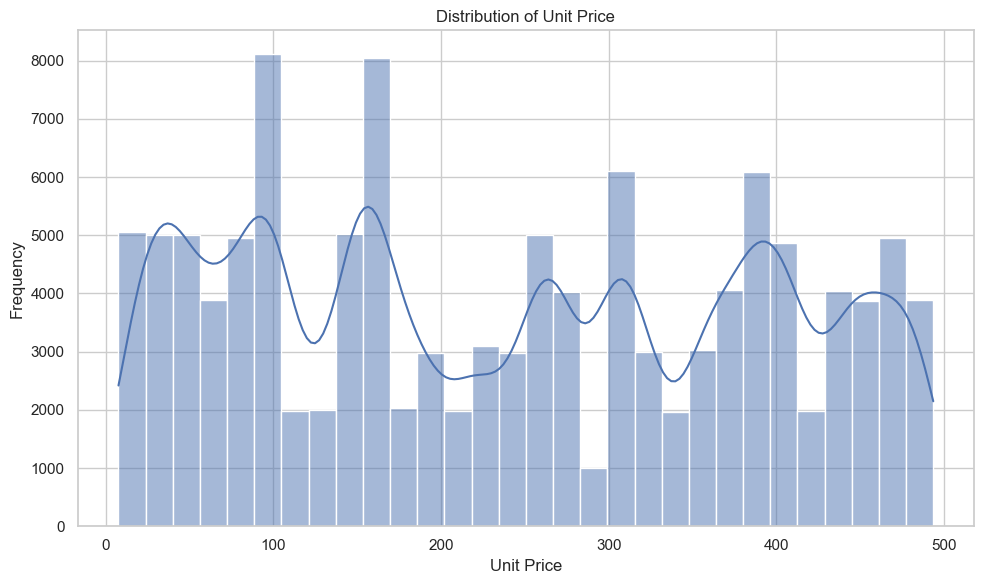

In [122]:
# Histogram for unit_price
plt.figure(figsize=(10, 6))
sns.histplot(df['unit_price'], kde=True, bins=30)
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

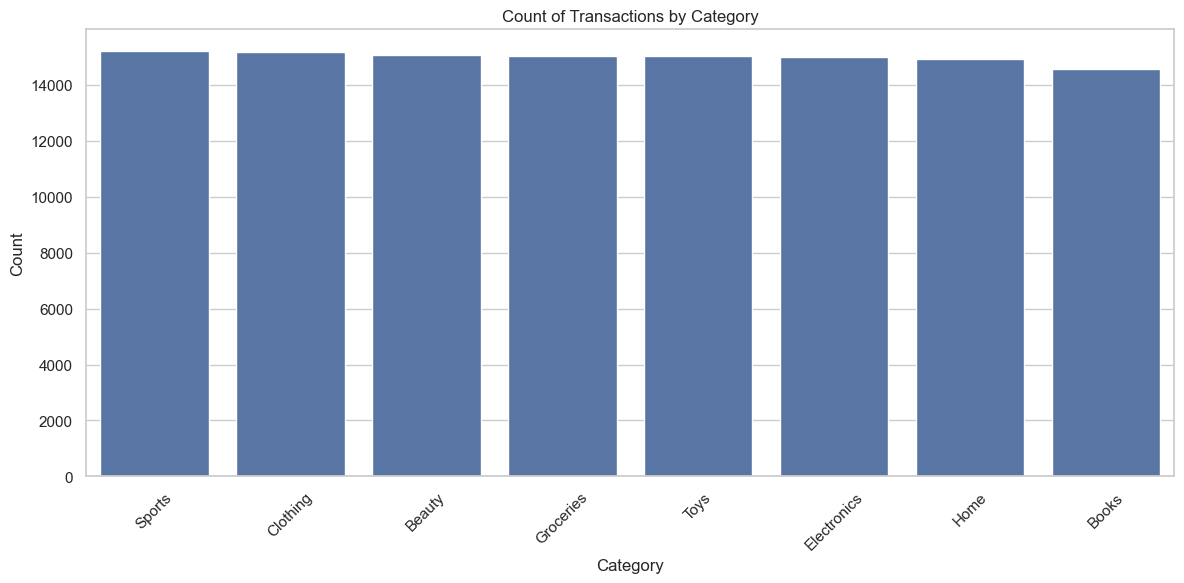

In [123]:
# Count plot for product categories
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='category', order=df['category'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Count of Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



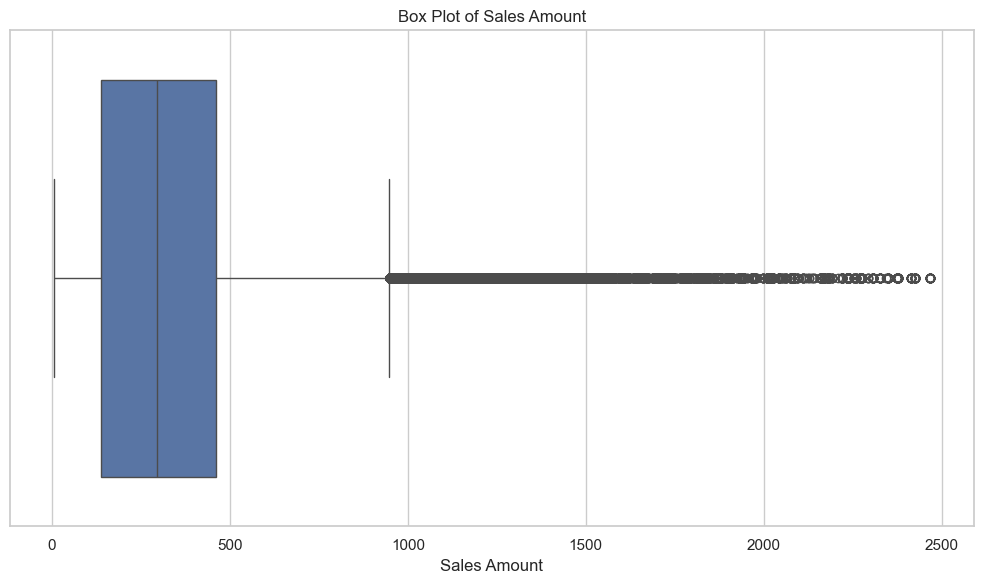

In [124]:
# Box plot for sales_amount
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sales_amount')
plt.title('Box Plot of Sales Amount')
plt.xlabel('Sales Amount')
plt.tight_layout()
plt.show()

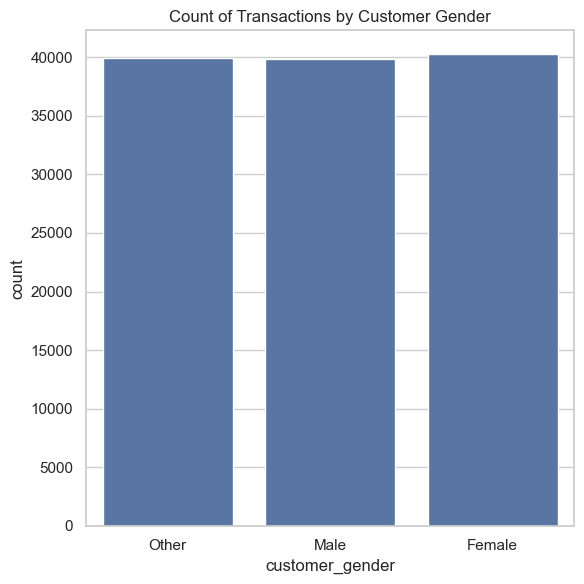

In [125]:
# Pie Chart style using countplot for customer_gender
plt.figure(figsize=(6, 6))
gender_counts = df['customer_gender'].value_counts()
sns.countplot(x='customer_gender', data=df)
plt.title('Count of Transactions by Customer Gender')
plt.tight_layout()
plt.show()

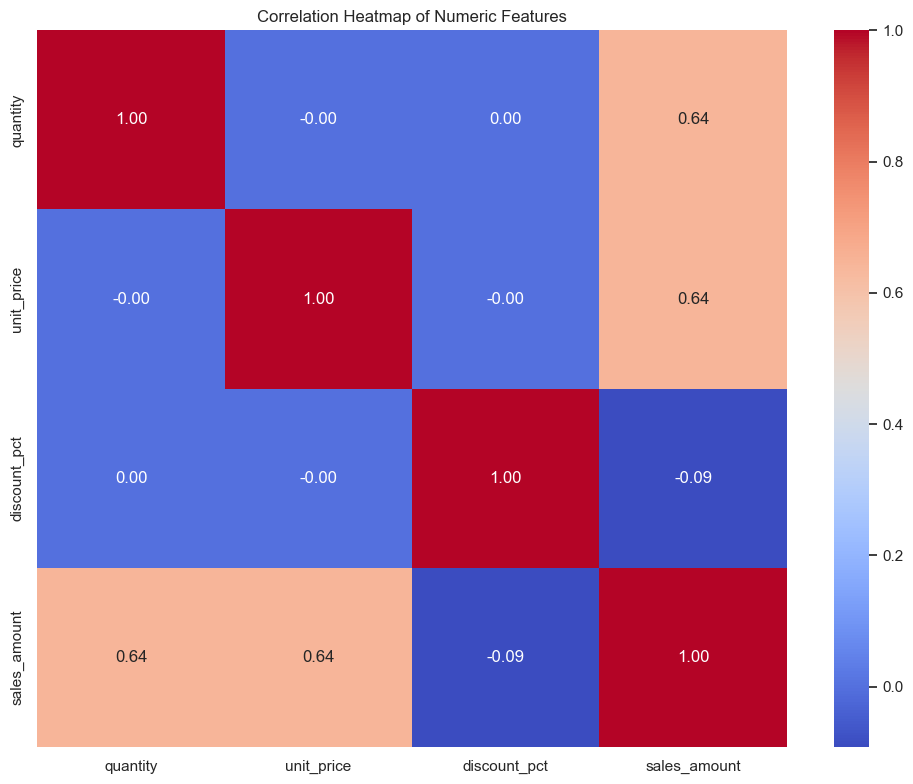

In [127]:
# If enough numeric columns, display a correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

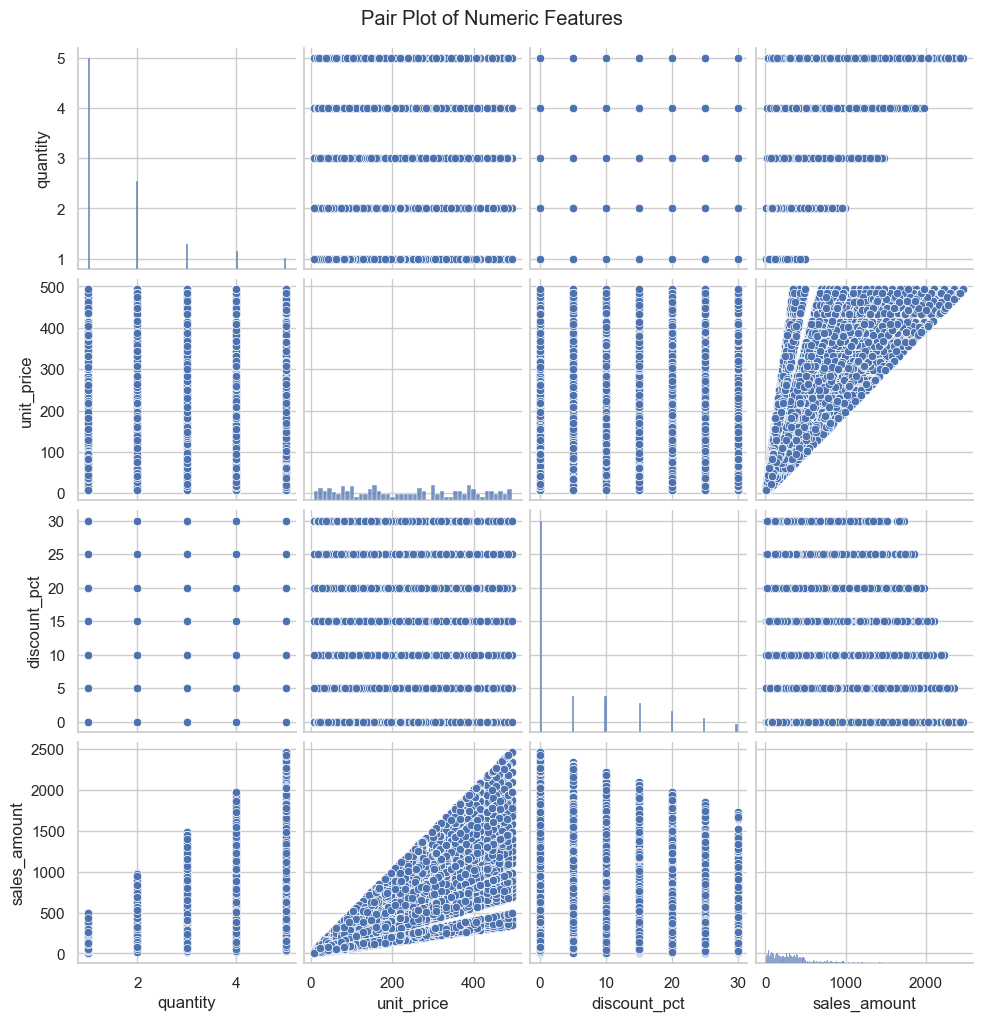

In [128]:
# Pair plot for a subset of numeric columns (if there are at least two numeric features)
if numeric_df.shape[1] >= 2:
    sns.pairplot(numeric_df)
    plt.suptitle('Pair Plot of Numeric Features', y=1.02)
    plt.show()

In [130]:
#One of the most exciting parts of data science is the creation of predictive models. Here, we attempt to predict the sales_amount using a linear regression model. We select a few features that are likely to influence sales: quantity, unit_price, and discount_pct. Of course, this is a simplistic model and more features – including engineered ones – could be added for improvement.


R2 Score for predicting sales_amount: 0.839


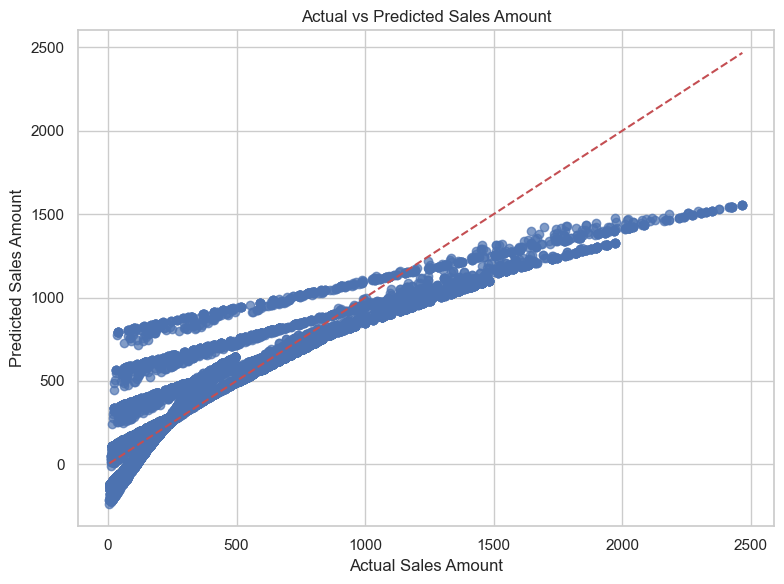

In [132]:
# Define the feature matrix X and target vector y for prediction
features = ['quantity', 'unit_price', 'discount_pct']
X = df[features]
y = df['sales_amount']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the R2 score as a measure of prediction accuracy
accuracy = r2_score(y_test, y_pred)
print(f"R2 Score for predicting sales_amount: {accuracy:.3f}")

# Optional: Plot the predicted vs actual sales amounts
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Sales Amount')
plt.ylabel('Predicted Sales Amount')
plt.title('Actual vs Predicted Sales Amount')
plt.tight_layout()
plt.show()